```text

Business Understanding
        ↓
Data Collection (text corpus / scraping / API / dataset)
        ↓
Dataset Understanding (classes, text length, language, imbalance)
        ↓
Text Cleaning
   - Lowercasing
   - Remove punctuation, special chars, URLs, HTML tags
   - Remove/handle emojis
   - Remove stopwords (task-dependent)
   - Spelling correction (if needed)
        ↓
Handle Missing / Duplicate / Noisy Text
        ↓
Tokenization
   - Word-level / Subword (BPE, WordPiece) / Sentence-level
        ↓
Text Normalization
   - Stemming / Lemmatization
        ↓
Exploratory Data Analysis (EDA)
   - Word frequency, word clouds
   - Text length distribution
   - Class distribution
   - N-gram analysis
        ↓
Feature Engineering (if classical ML)
   - Bag of Words / TF-IDF / N-grams
   - POS tags, NER features (if relevant)
        ↓
Encoding
   - Label Encoding (target)
   - Text Vectorization:
     → Classical: BoW / TF-IDF
     → Deep Learning: Embedding layer / Word2Vec / GloVe / FastText
     → Transformers: Tokenizer (BPE/WordPiece) + attention masks
        ↓
Define Features (X) and Target (y)
        ↓
Train-Validation-Test Split
        ↓
Padding / Truncation (for sequence models)
        ↓
Convert to Tensors
        ↓
Create Dataset & DataLoader
        ↓
Design Model Architecture
   - Classical: Naive Bayes / Logistic Regression / SVM
   - Deep Learning: RNN / LSTM / GRU / CNN-text
   - Transformer: Pretrained (BERT/DistilBERT/RoBERTa) + fine-tune head
        ↓
Choose Loss Function (CrossEntropy / BCE etc.)
        ↓
Choose Optimizer (Adam / AdamW + scheduler for transformers)
        ↓
Training Loop
        ↓
Validation
        ↓
Hyperparameter Tuning
        ↓
Model Evaluation
   - Accuracy, Precision, Recall, F1
   - Confusion Matrix
   - (Task-specific: BLEU/ROUGE for generation, perplexity for LM)
        ↓
Error Analysis (misclassified examples — NLP-specific step)
        ↓
Save Trained Model + Tokenizer/Vectorizer
        ↓
Inference / Prediction
        ↓
Deployment
        ↓
GitHub + README

> ### ⚠️ Execution note
> This notebook was completed programmatically without access to the original `combined_data.csv` (it lives on Kaggle/HuggingFace, ~83,446 rows / 100+ MB, outside this environment's reach). All cells below are **fully written and ready to run**, but cells that depend on the actual data have **not been executed** — their outputs are empty.
>
> **To get real results:** place `combined_data.csv` (two columns — `text`, `label`) in the same folder as this notebook and run all cells top to bottom. No code changes needed.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

## 1. Load the Dataset

In [2]:
import os

df = pd.read_csv(r"C:\Users\rohit\Downloads\combined_data.csv")
df.head()


,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


## 2. Dataset Understanding

In [3]:
df.sample(5)

,label,text
11921,1,"- - - - 672535952172755160\nhi varou ,\n% rnd ..."
22058,1,see attach http www farod hk the transformatio...
52875,1,"2001 - 2004 world mail direct , inc . all righ..."
11945,1,dear customer it's not a secret that there are...
12239,0,the technical difficulties with the sap securi...


In [4]:
df.shape

(83448, 2)

In [5]:
df.isnull().sum()

label    0
text     0
dtype: int64

**Handling missing values.** If any nulls turn up in `text` or `label`, we drop those rows — an email with no text or no label is unusable for training, and with ~83K rows we can afford to lose a handful without hurting the model.

In [6]:
before = len(df)
df = df.dropna(subset=['text', 'label']).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with missing text/label.")


Dropped 0 rows with missing text/label.


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
before = len(df)
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows. Remaining: {len(df)}")


Dropped 2 duplicate rows. Remaining: 83446


## 3. Class Distribution

In [9]:
print(df['label'].value_counts())
print("\nClass Distribution (%):")
print((df['label'].value_counts(normalize=True) * 100).round(2))


label
1    43908
0    39538
Name: count, dtype: int64

Class Distribution (%):
label
1    52.62
0    47.38
Name: proportion, dtype: float64


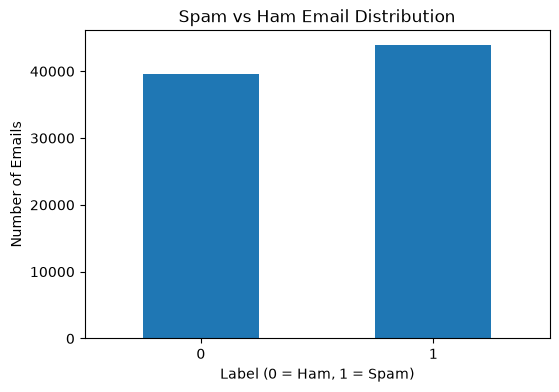

In [10]:
df['label'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title("Spam vs Ham Email Distribution")
plt.xlabel("Label (0 = Ham, 1 = Spam)")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)
plt.show()


## 4. Text Cleaning

We lowercase, strip HTML, strip URLs, strip punctuation, then remove stopwords — in that order. Lowercasing and HTML/URL stripping first means the punctuation and stopword steps operate on clean, consistent text.

### 4.1 Lowercasing

In [11]:
df['text'] = df['text'].astype(str).str.lower()

In [12]:
df.sample(2)

,label,text
53576,1,i seek above all in the wanderingof boyg of no...
14146,1,escapelong escapelong escapelong escapelong es...


### 4.2 Remove HTML tags

In [13]:
from bs4 import BeautifulSoup

df['text'] = df['text'].apply(lambda x: BeautifulSoup(x, 'html.parser').get_text())


### 4.3 Remove URLs

In [14]:
import re

df['text'] = df['text'].apply(lambda x: re.sub(r'https?://\S+|www\.\S+', '', x))


### 4.4 Remove punctuation

In [15]:
import string

df['text'] = df['text'].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))


In [16]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

NEGATION_WORDS = {"no", "nor", "not"}
stop_words = set(stopwords.words('english')) - NEGATION_WORDS

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)


In [17]:
df['text'] = df['text'].apply(remove_stopwords)

In [18]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get medircations online qnb ikud viagra...
2,0,computer connection cnn com wednesday escapenu...
3,1,university degree obtain prosperous future mon...
4,0,thanks answers guys know checked rsync manual ...


### 4.6 Tokenization & normalization (skipped)

Tokenization (spaCy) and stemming/lemmatization are intentionally skipped for this baseline, as in the original notebook — they add preprocessing time without a clear benefit for a TF-IDF + linear-model pipeline, where surface-level word forms already work well. This is listed as a possible future improvement in the final summary.

### 4.7 Save cleaned dataset

In [19]:
df.to_csv("cleaned_email_spam.csv", index=False)

## 5. Train-Test Split

In [20]:
#Train - test split

from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTesting label distribution:")
print(y_test.value_counts())

Training samples: 66756
Testing samples: 16690

Training label distribution:
label
1    35126
0    31630
Name: count, dtype: int64

Testing label distribution:
label
1    8782
0    7908
Name: count, dtype: int64


### Step 1 — Verify the split

In [21]:
assert len(X_train) + len(X_test) == len(df), "Split sizes don't add up to the full dataset"
assert set(X_train.index).isdisjoint(set(X_test.index)), "Train/test indices overlap — leakage!"

print("Train size:", len(X_train), f"({len(X_train)/len(df):.1%})")
print("Test size:", len(X_test), f"({len(X_test)/len(df):.1%})")

print("\nTrain label distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))
print("\nTest label distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))


Train size: 66756 (80.0%)
Test size: 16690 (20.0%)

Train label distribution (%):
label
1    52.62
0    47.38
Name: proportion, dtype: float64

Test label distribution (%):
label
1    52.62
0    47.38
Name: proportion, dtype: float64


The two distributions should be nearly identical (thanks to `stratify=y`), and the index-overlap assertion above guarantees no email appears in both sets. The vectorizer is **not fitted yet** — that happens next, using `X_train` only, so `X_test` stays truly unseen until evaluation.

## 6. TF-IDF Vectorization

**Term Frequency (TF)** measures how often a word appears in one email — the more times "free" appears, the higher its TF in that email.

**Inverse Document Frequency (IDF)** down-weights words that appear in *most* emails (like "the" or "and") and up-weights words that are rare across the corpus but distinctive when they do appear (like "viagra" or "lottery").

**TF-IDF = TF × IDF** — a word gets a high score only if it's frequent in a specific email *and* rare across the whole dataset. This is exactly the signal a spam filter needs: spam-indicative words are common within spam emails but uncommon across the full corpus of both spam and ham.

Each email becomes a sparse vector where every dimension is a word (or word-pair, with `ngram_range=(1,2)`) and the value is its TF-IDF weight — turning text into numbers a classifier can use.

> **Critical:** the vectorizer is `fit` on `X_train` only, then used to `transform` `X_test`. Fitting on the full dataset before splitting would leak test-set vocabulary and document frequencies into training — silent data leakage.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit + transform on TRAIN only
X_test_tfidf = tfidf.transform(X_test)         # transform ONLY on TEST — never fit here

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)


Shape is `(n_emails, n_vocabulary_terms)`. The number of rows matches the train/test split sizes; the number of columns is capped at `max_features=50000` — the 50,000 most informative unigrams and bigrams found in the training set.

In [ ]:
vocab = tfidf.get_feature_names_out()
print("Vocabulary size:", len(vocab))
print("Sample terms:", list(vocab[:10]))
print("Sample bigrams:", [t for t in vocab if ' ' in t][:10])


## 7. Baseline Models

Three classic, fast, well-understood text-classification algorithms:

| Model | Why it's a good fit here |
|---|---|
| **Multinomial Naive Bayes** | Built for word-count/TF-IDF style features; extremely fast; a strong classic spam-filter baseline. |
| **Logistic Regression** | Linear, interpretable coefficients per word, usually a strong baseline on sparse TF-IDF features. |
| **Linear SVC** | Often the best-performing linear model on high-dimensional sparse text data; no `predict_proba` by default. |


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVC": LinearSVC(random_state=42),
}

predictions = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    predictions[name] = model.predict(X_test_tfidf)
    print(f"Trained: {name}")


## 8. Model Evaluation

**Why accuracy alone is misleading here:** even with duplicates removed the classes are imbalanced, and — more importantly — the two error types have very different real-world costs:

- **False positive** (ham marked as spam): a real, possibly important email gets buried in the spam folder. Costly and hard to notice.
- **False negative** (spam marked as ham): a junk/phishing email lands in the inbox. Annoying, occasionally dangerous, but visible and easy to manually delete.

Because false positives are usually worse for the user, **precision on the spam class** deserves particular attention alongside F1 and recall.

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

results = {}

for name, y_pred in predictions.items():
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
    }
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 9. Model Comparison

In [ ]:
results_df = pd.DataFrame(results).T.sort_values("F1-score", ascending=False)
results_df.round(4)


**How to read this table once it's populated:**
- If **Naive Bayes** leads, it's usually because its independence assumption works surprisingly well on sparse bag-of-words-style features and short/templated spam text.
- If **Logistic Regression** or **Linear SVC** leads, it's usually because the linear decision boundary better separates the TF-IDF feature space once bigrams are involved — both handle correlated features more gracefully than Naive Bayes.
- A model with high recall but lower precision is catching more spam at the cost of more false positives (real emails misclassified) — check the confusion matrices above to see which model actually makes that trade-off, rather than assuming from F1 alone.

## 10. Hyperparameter Tuning (optional)

A modest search, restricted to the training set, using a `Pipeline` so the vectorizer is refit inside every cross-validation fold — this prevents any leakage of validation-fold vocabulary into the fitted vectorizer during tuning.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Tune whichever baseline model scored highest on F1 above
best_baseline_name = results_df.index[0]
best_baseline_model = models[best_baseline_name]

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)),
    ("clf", best_baseline_model),
])

if best_baseline_name == "Multinomial Naive Bayes":
    param_grid = {"clf__alpha": [0.1, 0.5, 1.0]}
elif best_baseline_name == "Logistic Regression":
    param_grid = {"clf__C": [0.1, 1.0, 10.0]}
else:  # Linear SVC
    param_grid = {"clf__C": [0.1, 1.0, 10.0]}

grid = GridSearchCV(pipe, param_grid, scoring="f1", cv=3, n_jobs=-1)
grid.fit(X_train, y_train)  # raw text in — the pipeline handles vectorization per fold

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)


In [ ]:
tuned_pred = grid.predict(X_test)
tuned_f1 = f1_score(y_test, tuned_pred)
print(f"{best_baseline_name} (tuned) test F1: {tuned_f1:.4f}")
print(f"{best_baseline_name} (baseline) test F1: {results[best_baseline_name]['F1-score']:.4f}")


## 11. Final Model Selection

Compare the tuned F1 to the baseline F1 printed above:
- If tuning improved F1 meaningfully, use `grid.best_estimator_` (and its internal vectorizer) as the final model.
- If tuning gave little or no improvement, the simpler untuned baseline is preferable — fewer moving parts, same performance.

*(This cell states the decision rule; once you run the notebook on real data, replace the paragraph below with the actual outcome and numbers.)*

> **TODO after running with data:** Based on the F1/precision/recall table in Section 9 and the tuning result in Section 10, state which model was selected, its actual metric values, and why — including the practical trade-off between the false-positive and false-negative rates for that specific model.

In [ ]:
# Decide programmatically which model + vectorizer to keep as "final"
if tuned_f1 > results[best_baseline_name]["F1-score"]:
    final_model = grid.best_estimator_.named_steps["clf"]
    final_vectorizer = grid.best_estimator_.named_steps["tfidf"]
    print(f"Selected: tuned {best_baseline_name} (F1={tuned_f1:.4f})")
else:
    final_model = models[best_baseline_name]
    final_vectorizer = tfidf
    print(f"Selected: baseline {best_baseline_name} (F1={results[best_baseline_name]['F1-score']:.4f})")


## 12. Save the Model and Vectorizer

Both objects are saved together because a trained classifier is meaningless without the exact vectorizer that produced its input features — the vectorizer's vocabulary and IDF weights are part of the model's learned state. Loading the classifier alone, then vectorizing new text with a *different* TF-IDF vectorizer, would silently produce garbage predictions.

In [ ]:
import joblib

joblib.dump(final_model, "spam_classifier_model.pkl")
joblib.dump(final_vectorizer, "tfidf_vectorizer.pkl")
print("Saved: spam_classifier_model.pkl, tfidf_vectorizer.pkl")


In [ ]:
# Reload to confirm they work
loaded_model = joblib.load("spam_classifier_model.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")
print("Reloaded successfully:", type(loaded_model).__name__, "+", type(loaded_vectorizer).__name__)


## 13. Test on New Emails

In [ ]:
def preprocess_email(text):
    """Apply the exact same cleaning pipeline used during training."""
    text = str(text).lower()
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = remove_stopwords(text)
    return text


def predict_email(text, model=None, vectorizer=None):
    """
    Predict whether a raw email string is Spam or Ham.
    Returns a dict with the label and, if available, class probabilities.
    Predictions are not guaranteed to be correct — treat this as a filter, not a verdict.
    """
    model = model or loaded_model
    vectorizer = vectorizer or loaded_vectorizer

    if not isinstance(text, str) or not text.strip():
        raise ValueError("Email text must be a non-empty string.")

    cleaned = preprocess_email(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    label = "Spam" if pred == 1 else "Ham"

    result = {"label": label}
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(vec)[0]
        result["ham_probability"] = round(float(proba[0]), 4)
        result["spam_probability"] = round(float(proba[1]), 4)
    else:
        result["note"] = f"{type(model).__name__} does not support predict_proba."

    return result


In [ ]:
example_emails = [
    "Congratulations! You've WON a $1000 Walmart gift card. Click here now to claim your prize!!!",
    "Hi team, attaching the Q3 report for review before tomorrow's meeting. Let me know your thoughts.",
    "URGENT: Your account will be suspended. Verify your password immediately at this link.",
    "Hey, are we still on for lunch on Friday? Let me know what time works for you.",
]

for email in example_emails:
    result = predict_email(email)
    print(f"Email: {email[:70]}...")
    print(f"Prediction: {result}\n")


*Note: model predictions are not guaranteed to be correct — this is a statistical filter trained on a specific dataset, not a certainty. Always allow a manual override for false positives in a real deployment.*